# Telco Customer Churn Exploratory Data Analysis
This notebook performs concise, focused EDA: data quality, distributions, target analysis, bivariate relationships, correlations, and a quick baseline model. All plots and tables are displayed inline only.

In [ ]:
# Imports and display settings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import warnings
warnings.filterwarnings("ignore")
sns.set(style="whitegrid")
pd.options.display.max_columns = 200
pd.options.display.width = 120

# Load and basic checks
DATA_PATH = "../data/telco_customer_churn.csv"
df = pd.read_csv(DATA_PATH)

# Convert TotalCharges if present
if 'TotalCharges' in df.columns:
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Quick overview
print("Rows, Columns:", df.shape)
display(df.head(3))
display(df.dtypes.to_frame('dtype').T)

# Missingness and unique counts
missing = df.isna().sum().sort_values(ascending=False)
unique_counts = df.nunique().sort_values()
display(missing[missing > 0])
display(unique_counts.head(20))

# Small sample row for UI template (display only)
display(df.sample(1, random_state=42))

Rows, Columns: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
dtype,object,object,int64,object,object,int64,object,object,object,object,object,object,object,object,object,object,object,object,float64,float64,object


TotalCharges    11
dtype: int64

gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
PhoneService           2
PaperlessBilling       2
Churn                  2
MultipleLines          3
TechSupport            3
StreamingTV            3
OnlineBackup           3
DeviceProtection       3
StreamingMovies        3
Contract               3
OnlineSecurity         3
InternetService        3
PaymentMethod          4
tenure                73
MonthlyCharges      1585
TotalCharges        6530
dtype: int64

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,24.8,24.8,Yes


,count
Churn,
No,5174
Yes,1869


,proportion
Churn,
No,0.73463
Yes,0.26537


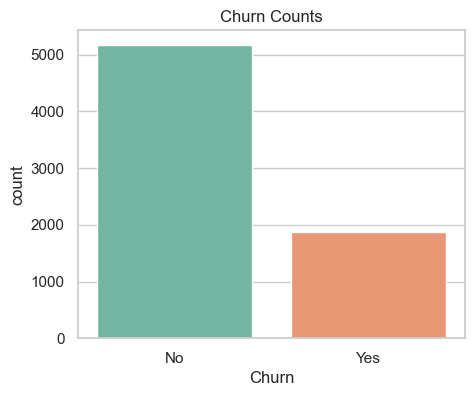

In [3]:
# Target analysis
if 'Churn' in df.columns:
    churn_counts = df['Churn'].value_counts(dropna=False)
    churn_rate = df['Churn'].value_counts(normalize=True)
    display(churn_counts.to_frame('count'))
    display(churn_rate.to_frame('proportion'))
    # Bar plot inline
    plt.figure(figsize=(5,4))
    sns.countplot(x='Churn', data=df, palette='Set2')
    plt.title('Churn Counts')
    plt.show()
else:
    print("No 'Churn' column found in dataset.")

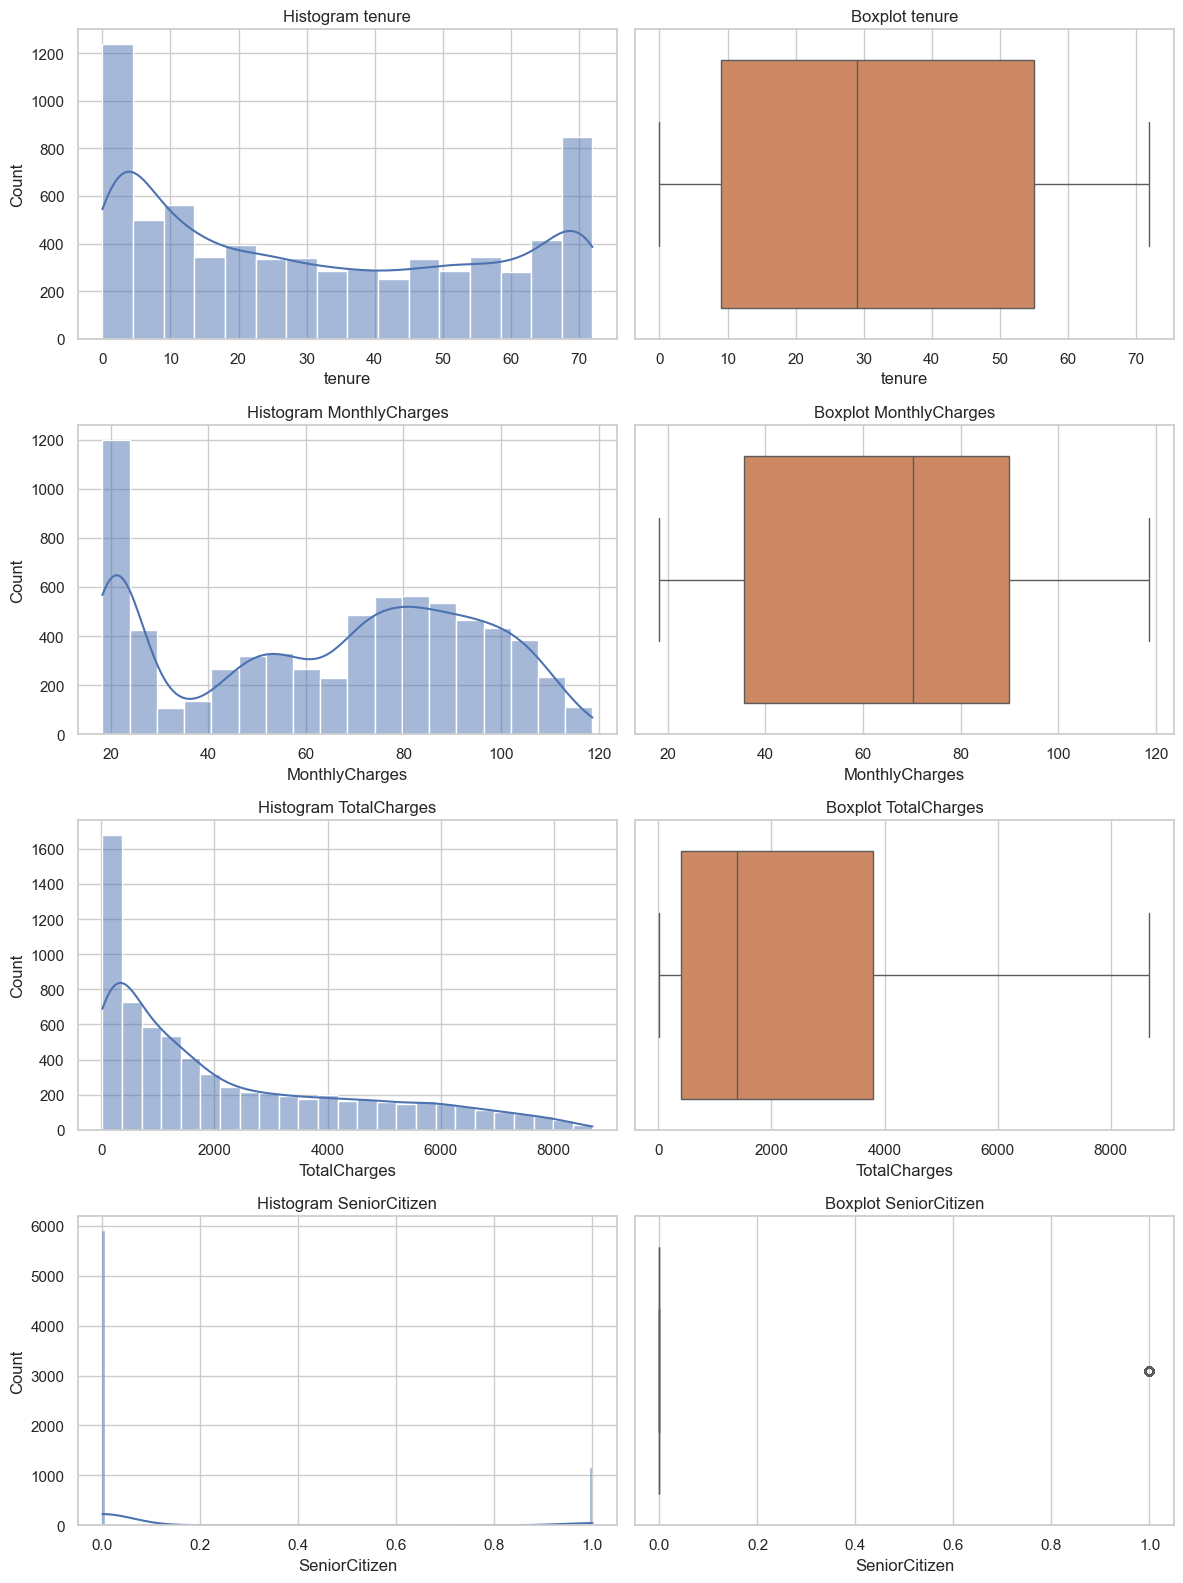

In [4]:
# Numeric distributions
num_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
# Exclude ID-like columns if present
num_cols = [c for c in num_cols if c.lower() not in ('customerid','id')]

# Select a concise set of numeric features to visualize
plot_cols = [c for c in ['tenure','MonthlyCharges','TotalCharges'] if c in num_cols]
plot_cols = plot_cols + [c for c in num_cols if c not in plot_cols][:2]  # up to 5 features

if plot_cols:
    fig, axes = plt.subplots(len(plot_cols), 2, figsize=(12, 4*len(plot_cols)))
    for i, col in enumerate(plot_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i,0], color='C0')
        axes[i,0].set_title(f'Histogram {col}')
        sns.boxplot(x=df[col], ax=axes[i,1], color='C1')
        axes[i,1].set_title(f'Boxplot {col}')
    plt.tight_layout()
    plt.show()
else:
    print("No numeric columns detected for plotting.")

Churn,No,Yes
Contract,,
Month-to-month,0.573,0.427
One year,0.887,0.113
Two year,0.972,0.028


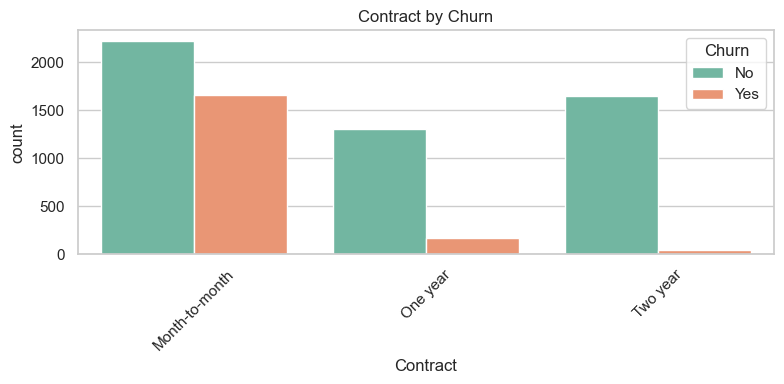

Churn,No,Yes
InternetService,,
Fiber optic,0.581,0.419
DSL,0.810,0.190
No,0.926,0.074


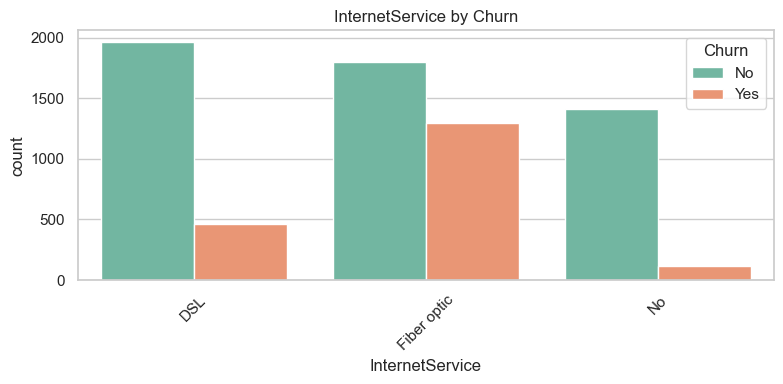

Churn,No,Yes
PaymentMethod,,
Electronic check,0.547,0.453
Mailed check,0.809,0.191
Bank transfer (automatic),0.833,0.167
Credit card (automatic),0.848,0.152


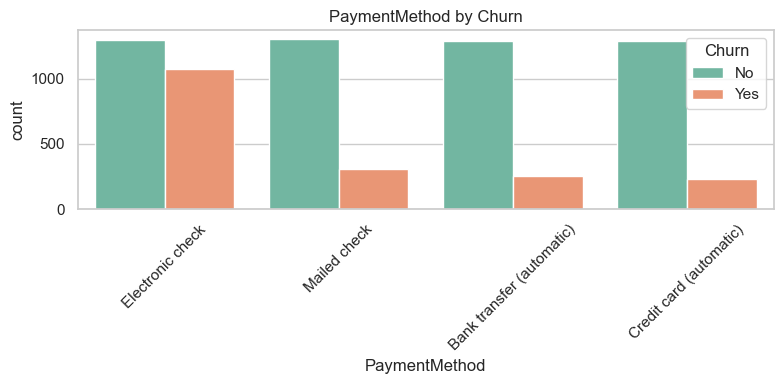

Churn,No,Yes
gender,,
Female,0.731,0.269
Male,0.738,0.262


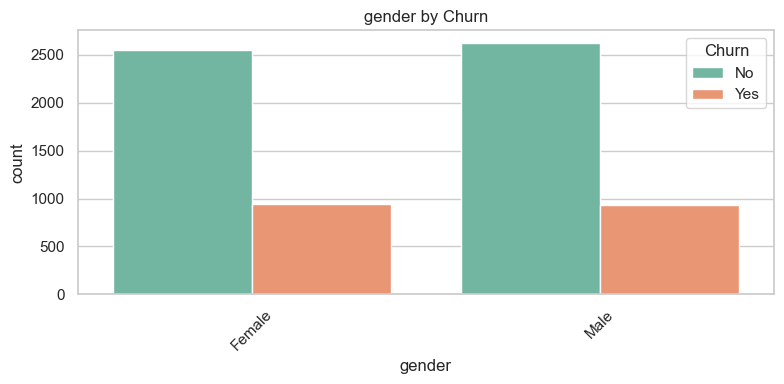

In [5]:
# Categorical analysis
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
cat_cols = [c for c in cat_cols if c.lower() not in ('customerid',)]

# Choose top categorical features by cardinality and business relevance
candidates = ['Contract','InternetService','PaymentMethod','gender','SeniorCitizen']
plot_cats = [c for c in candidates if c in cat_cols]
# fallback: top 5 categorical by frequency
if not plot_cats:
    plot_cats = cat_cols[:5]

for col in plot_cats:
    display(pd.crosstab(df[col], df['Churn'], normalize='index').round(3).sort_values(by='Yes' if 'Yes' in df['Churn'].unique() else df.columns[-1], ascending=False))
    plt.figure(figsize=(8,4))
    sns.countplot(x=col, hue='Churn', data=df, palette='Set2')
    plt.title(f'{col} by Churn')
    plt.xticks(rotation=45)
    plt.legend(title='Churn')
    plt.tight_layout()
    plt.show()

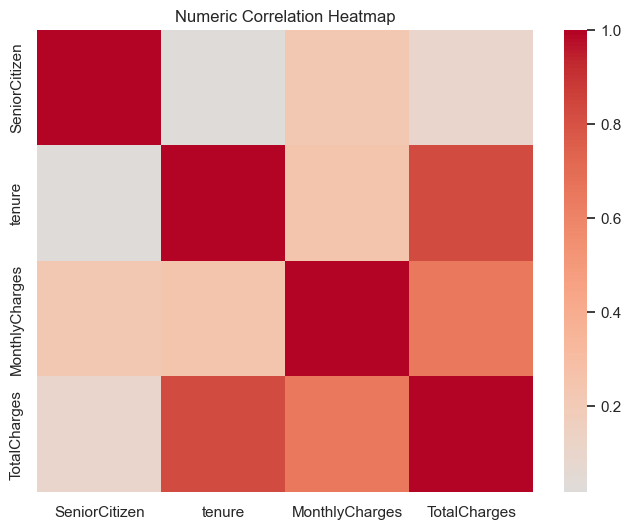

Baseline Logistic Regression AUC: 0.843


,abs_coef
Contract_Two year,1.193888
InternetService_Fiber optic,0.743929
Contract_One year,0.659048
PhoneService_Yes,0.481510
OnlineSecurity_Yes,0.415859
PaymentMethod_Electronic check,0.410568
TechSupport_Yes,0.383910
PaperlessBilling_Yes,0.348493
MultipleLines_Yes,0.272920
Dependents_Yes,0.240999



Next steps: feature engineering (tenure buckets, interaction terms), handle class imbalance, and train tree-based models (XGBoost/CatBoost) with stratified CV.


In [6]:
# Correlation and baseline
num = df.select_dtypes(include=['int64','float64'])
if not num.empty:
    corr = num.corr()
    plt.figure(figsize=(8,6))
    sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
    plt.title('Numeric Correlation Heatmap')
    plt.show()
else:
    print("No numeric features for correlation heatmap.")

# Quick baseline model (logistic) using simple one-hot encoding
if 'Churn' in df.columns:
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    from sklearn.metrics import roc_auc_score

    X = df.drop(columns=['customerID','Churn'], errors='ignore')
    # One-hot encode categorical features, fill numeric NaNs with median
    X_enc = pd.get_dummies(X, drop_first=True)
    X_enc = X_enc.fillna(X_enc.median())
    y = df['Churn'].map({'Yes':1,'No':0})

    # Keep dimensionality reasonable: select top features by variance if too many
    if X_enc.shape[1] > 200:
        variances = X_enc.var().sort_values(ascending=False)
        top_feats = variances.index[:200].tolist()
        X_enc = X_enc[top_feats]

    X_train, X_test, y_train, y_test = train_test_split(X_enc, y, stratify=y, test_size=0.2, random_state=42)
    clf = LogisticRegression(max_iter=1000, solver='liblinear')
    clf.fit(X_train, y_train)
    y_proba = clf.predict_proba(X_test)[:,1]
    auc = roc_auc_score(y_test, y_proba)
    print(f'Baseline Logistic Regression AUC: {auc:.3f}')
    display(pd.Series(clf.coef_[0], index=X_train.columns).abs().sort_values(ascending=False).head(10).to_frame('abs_coef'))
else:
    print("No Churn column; skipping baseline model.")

# Notebook next steps guidance
print("\nNext steps: feature engineering (tenure buckets, interaction terms), handle class imbalance, and train tree-based models (XGBoost/CatBoost) with stratified CV.")
